In [44]:
from sklearn.datasets import load_iris,load_breast_cancer,load_diabetes,fetch_california_housing
from sklearn.tree import DecisionTreeClassifier,plot_tree,DecisionTreeRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [45]:
X,y=load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y)

In [46]:
dt=load_breast_cancer(as_frame=True)['data']
y=load_breast_cancer(as_frame=True)['target']
X_train,X_test,y_train,y_test=train_test_split(dt,y)

In [47]:
dt.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


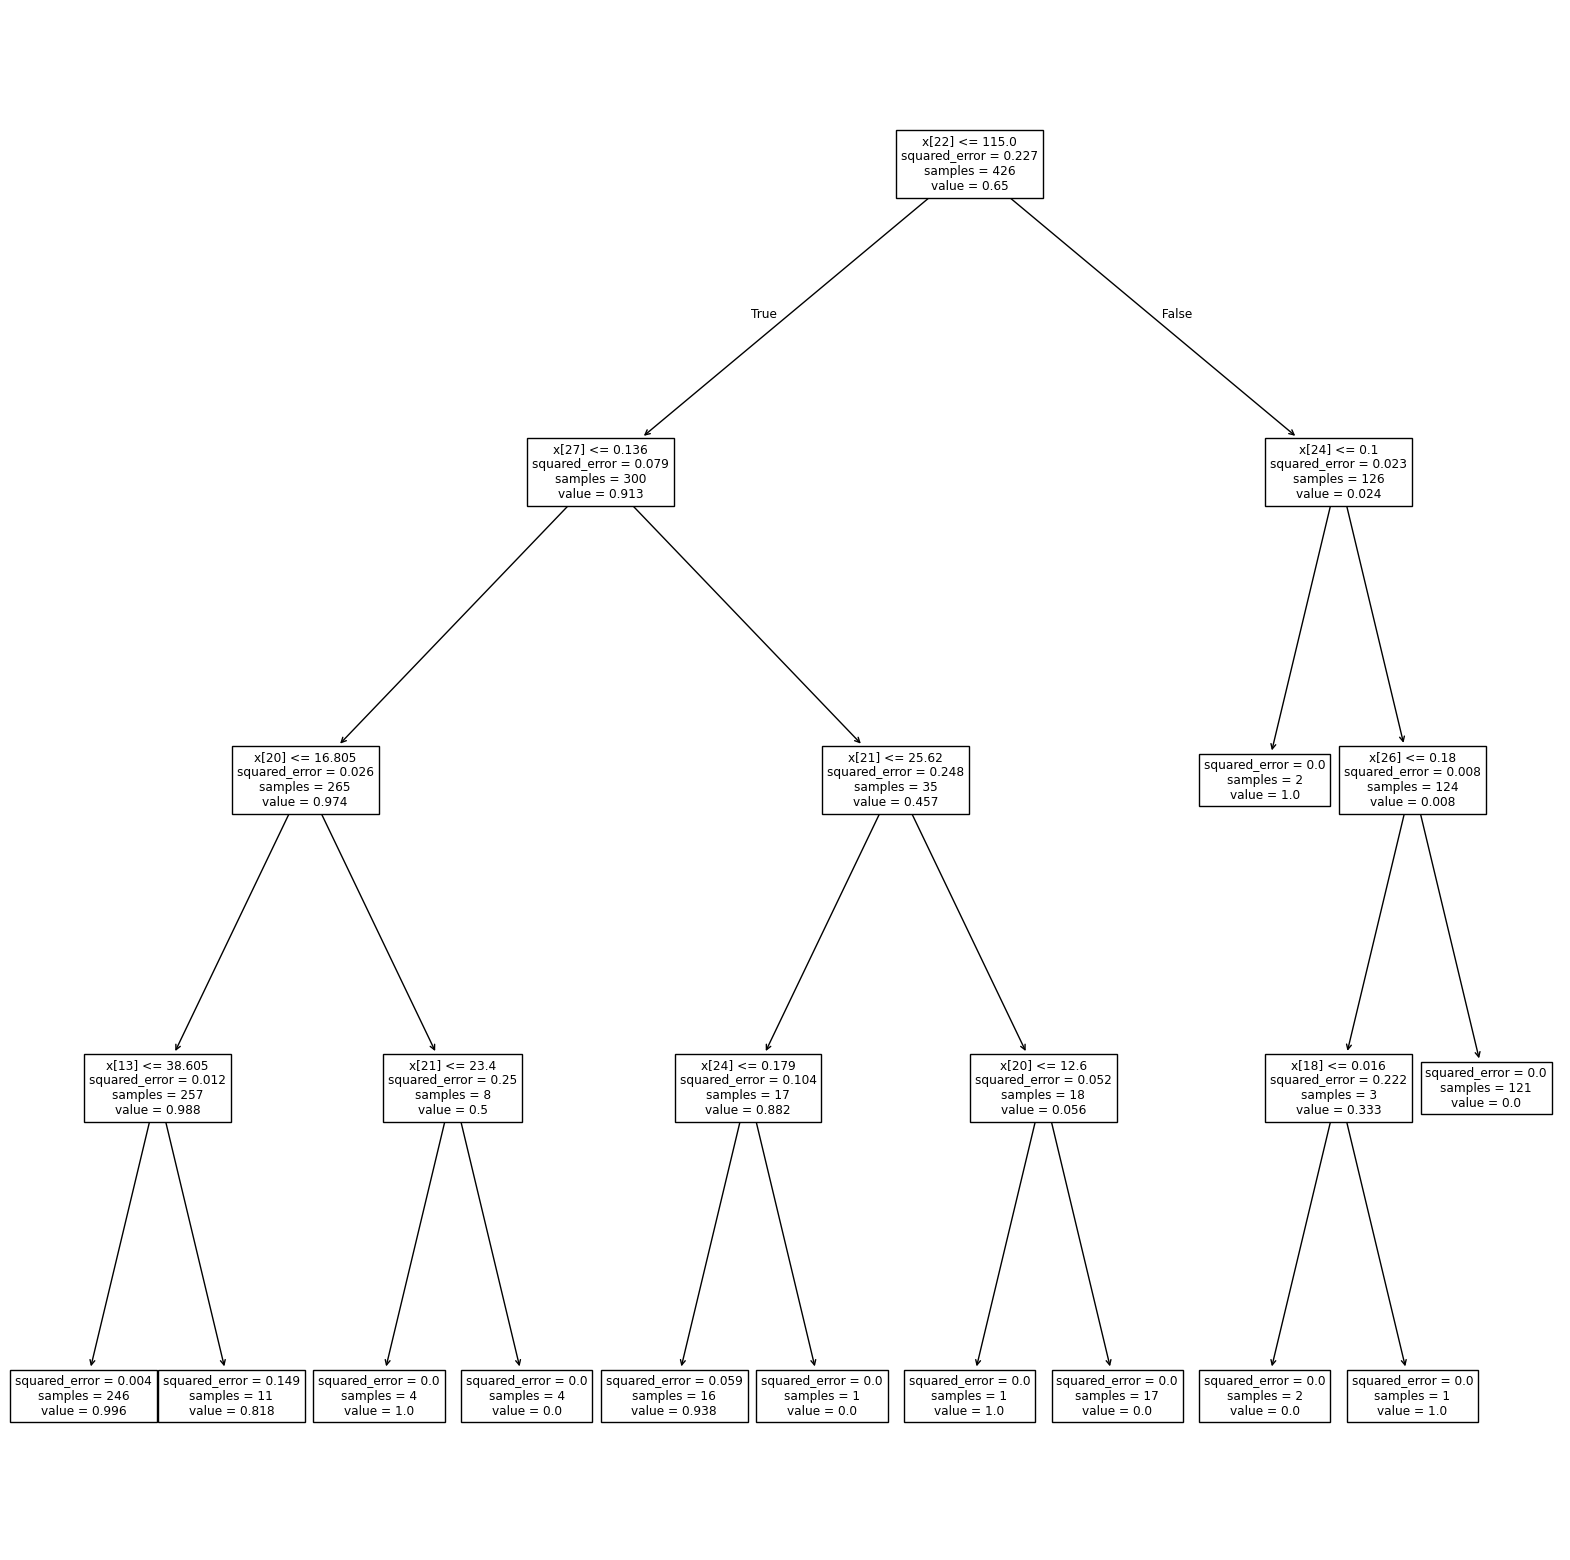

In [48]:
tree=DecisionTreeRegressor(max_depth=4)
tree.fit(X_train,y_train)
fig=plt.figure(figsize=(20,20))
plot_tree(tree);


In [49]:
tree=DecisionTreeClassifier()
params={'max_depth':[2,3,4,5,6,7,8]}
grid=GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=params)

In [50]:
grid.fit(X_train,y_train)
tree=DecisionTreeClassifier(max_depth=4)
tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


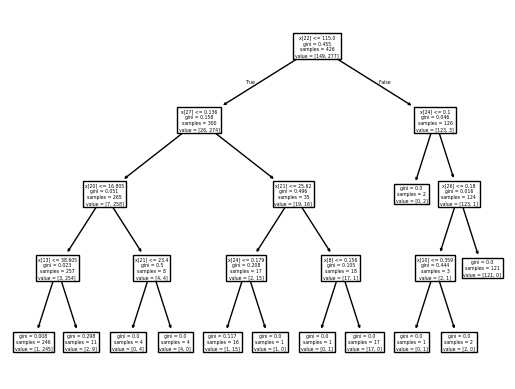

In [51]:
plot_tree(tree);

In [52]:
knn=KNeighborsClassifier()

In [53]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
for estimator in [knn,tree]:
    pred=estimator.predict(X_test)
    print(classification_report(y_true=y_test,y_pred=pred))
    print('='*20)

              precision    recall  f1-score   support

           0       0.96      0.86      0.91        63
           1       0.90      0.97      0.93        80

    accuracy                           0.92       143
   macro avg       0.93      0.92      0.92       143
weighted avg       0.93      0.92      0.92       143

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.95      0.96      0.96        80

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [55]:
svm_grid=GridSearchCV(estimator=SVC(),param_grid={'kernel':['rbf','poly','sigmoid']})
svm_grid.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'kernel': ['rbf', 'poly', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [56]:
lr=LogisticRegression(max_iter=4000)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,4000
,multi_class,'deprecated'


In [57]:
svm=SVC()# default kernel is rbf
svm.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [58]:
models={"KNN":knn,'Tree':tree,'SVM':svm,'LR':lr}
for key in models.keys():
    print(key)
    pred=models[key].predict(X_test)
    print(classification_report(y_true=y_test,y_pred=pred))
    print('='*20)

KNN
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        63
           1       0.90      0.97      0.93        80

    accuracy                           0.92       143
   macro avg       0.93      0.92      0.92       143
weighted avg       0.93      0.92      0.92       143

Tree
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.95      0.96      0.96        80

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

SVM
              precision    recall  f1-score   support

           0       0.98      0.78      0.87        63
           1       0.85      0.99      0.91        80

    accuracy                           0.90       143
   macro avg       0.91      0.88      0.89       143
weighted avg       0.91      0.90      0.89       143

LR
   